# Exploratory data analysis of final summary statistics

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import seaborn.objects as so
import numpy as np
import missingno as msno

In [2]:
csv = pd.read_csv("/home/maria/git/SOROLLA/SumStats/excell_sumstats_description.csv")

In [3]:
csv.drop(labels="ignore", axis=1, inplace=True)
csv.head()


,type,selection,title,pubmedId,efoTraits,disease,disease_subtype,label,condition_label,summaryStatistics,...,OR,se,p,N_col,N_num,Nca_col,Nca_val,Nco_col,Nco_val,INFO
0,NEU,subtype-family,"Genome-wide meta-analysis, fine-mapping and in...",33589840,alzheimer's disease,alzheimer's disease,family history,alzheimers-disease-family-history,ALZ,http://ftp.ebi.ac.uk/pub/databases/gwas/summar...,...,NaN,standard_error,p_value,NaN,408942,NaN,53042.0,NaN,355900.0,INFO
1,NEU,main,Genetic meta-analysis of diagnosed Alzheimer's...,30820047,late-onset Alzheimers disease,alzheimer's disease,NaN,alzheimers-late-onset-1,ALZ,http://ftp.ebi.ac.uk/pub/databases/gwas/summar...,...,NaN,SE,Pvalue,NaN,63926,NaN,21982.0,NaN,41944.0,NaN
2,NEU,minor,"Meta-analysis of 74,046 individuals identifies...",24162737,Alzheimer disease,alzheimer's disease,NaN,alzheimers-late-onset-4,ALZ,http://ftp.ebi.ac.uk/pub/databases/gwas/summar...,...,NaN,SE,Pvalue,NaN,55134,NaN,17008.0,NaN,37154.0,NaN
3,NEU,main,Common and rare variant association analyses i...,34873335,amyotrophic lateral sclerosis,amyotrophic lateral sclerosis,NaN,lateral-sclerosis-1,SCLE,http://ftp.ebi.ac.uk/pub/databases/gwas/summar...,...,NaN,standard_error,p_value,NaN,138086,NaN,27205.0,NaN,110881.0,NaN
4,NEU,minor,Genome-wide association analyses identify new ...,27455348,amyotrophic lateral sclerosis,amyotrophic lateral sclerosis,NaN,lateral-sclerosis-2,SCLE,http://ftp.ebi.ac.uk/pub/databases/gwas/summar...,...,NaN,standard_error,p_value,NaN,36052,NaN,12577.0,NaN,23475.0,NaN


<AxesSubplot: >

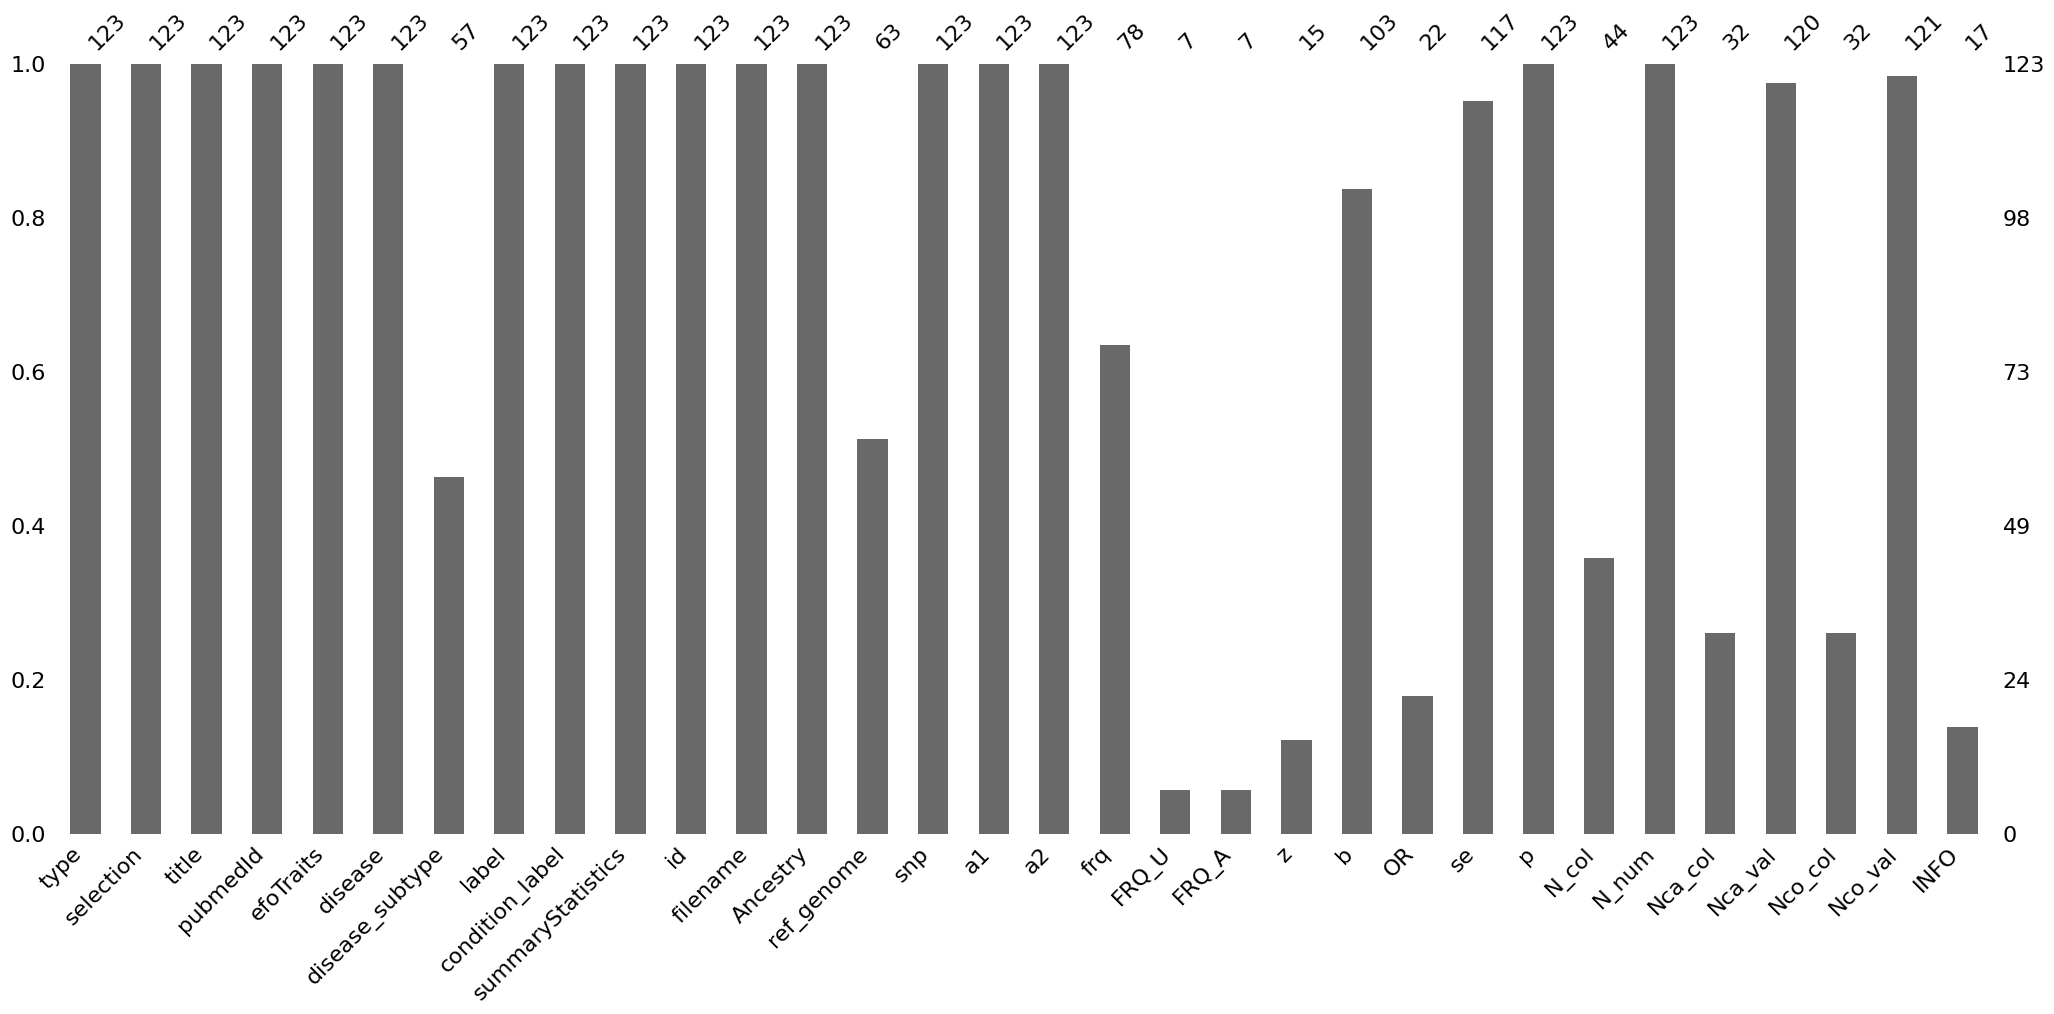

In [4]:
msno.bar(csv)

<AxesSubplot: >

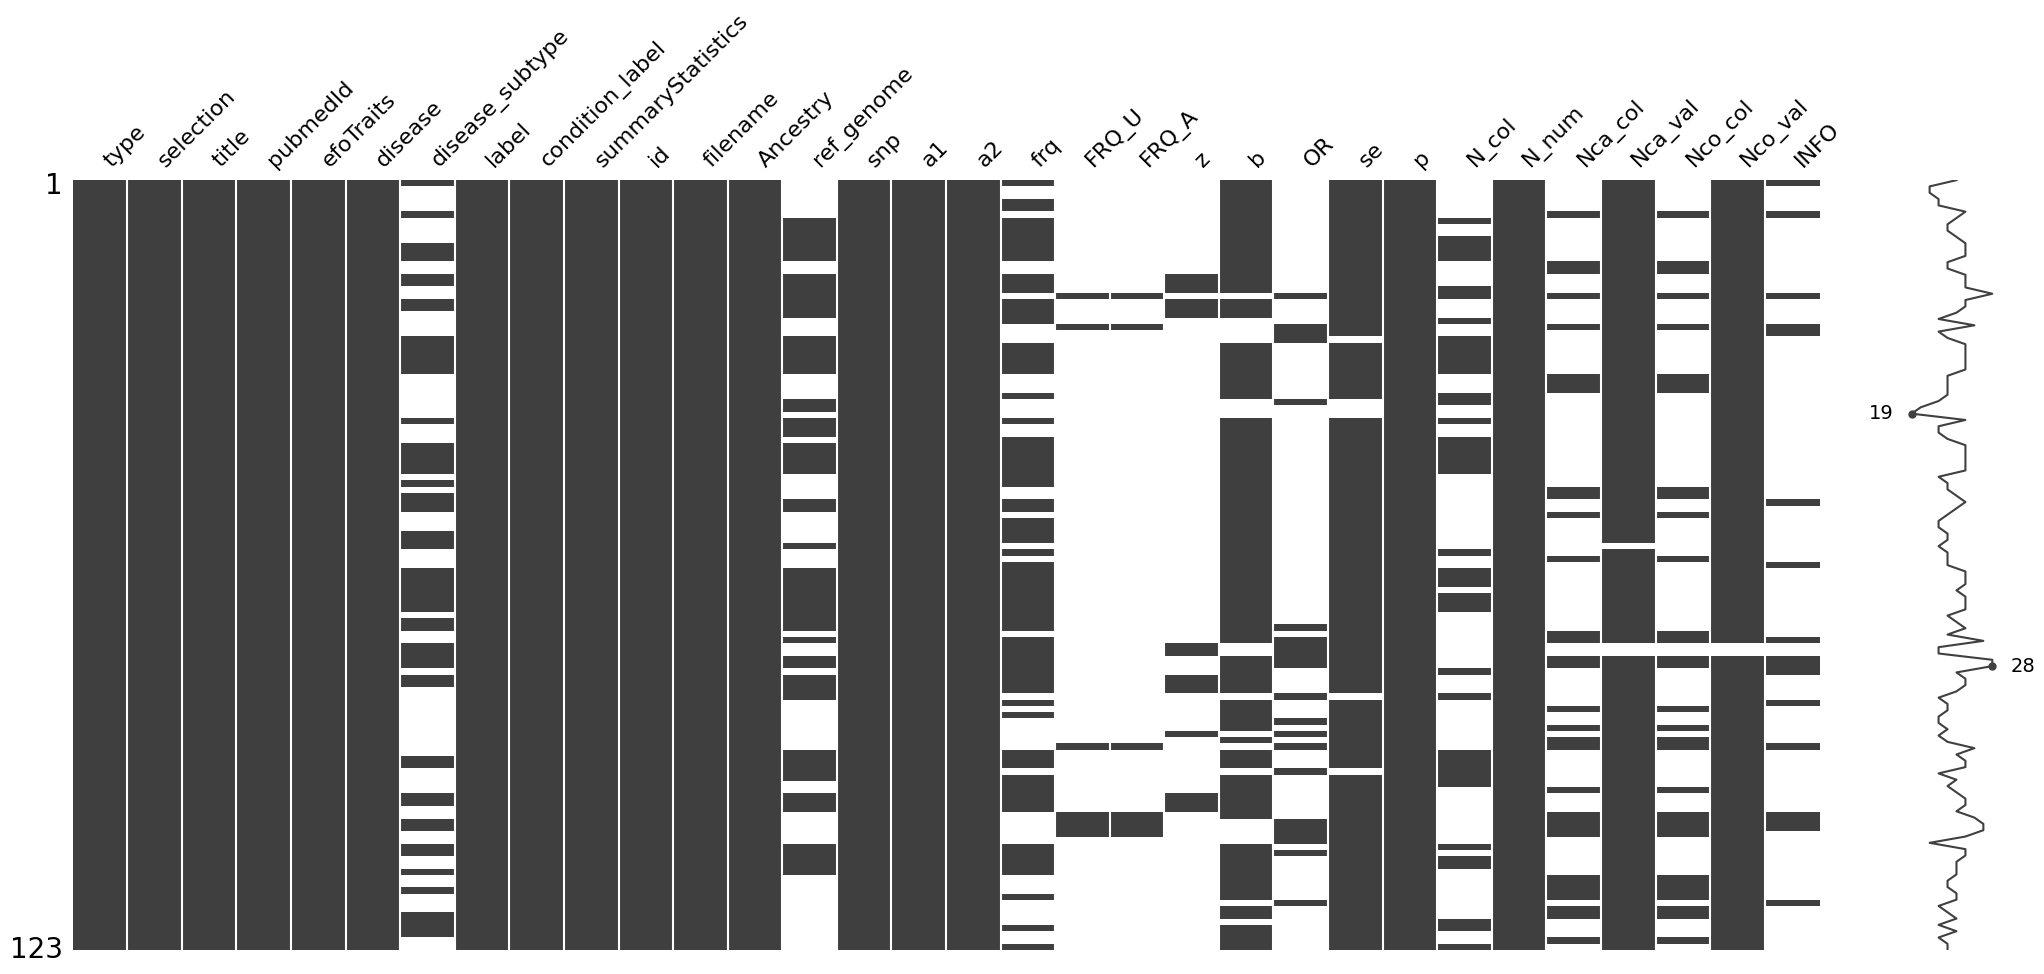

In [5]:
msno.matrix(csv)

In [6]:
csv['N_col'].fillna(value="N_added", inplace=True)
print(csv["N_col"].value_counts())

N_added            79
N                  32
totN                4
n                   3
N_col               2
N-col               2
TotalSampleSize     1
Name: N_col, dtype: int64


In [7]:
type_palette = {"CAN":"#FE6401", "PSY":"#6401FE","NEU":"#01FE64"}

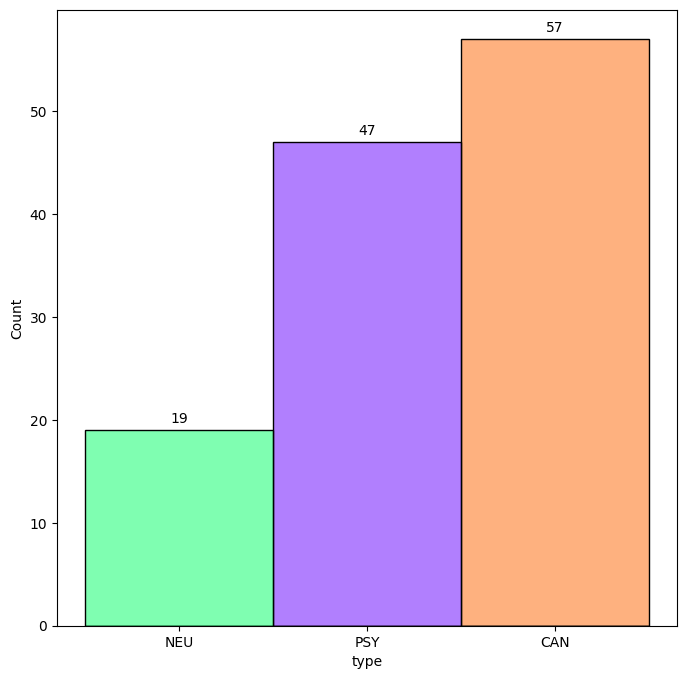

In [8]:
fig, ax = plt.subplots(figsize=(8, 8))

a = sns.histplot(csv, x = "type", hue = "type", palette=type_palette, legend=None, ax=ax)
for container in a.containers:
    labels = [f'{height:.0f}' if height > 0 else '' for height in container.datavalues]
    a.bar_label(container, labels=labels, label_type="edge", padding=3)

In [9]:
print(f"The number of unique diseases in the dataset is", len(csv["disease"].unique()))
print(f"The number of unique pubmedIds in the dataset is", len(csv["pubmedId"].unique()))

The number of unique diseases in the dataset is 38
The number of unique pubmedIds in the dataset is 41


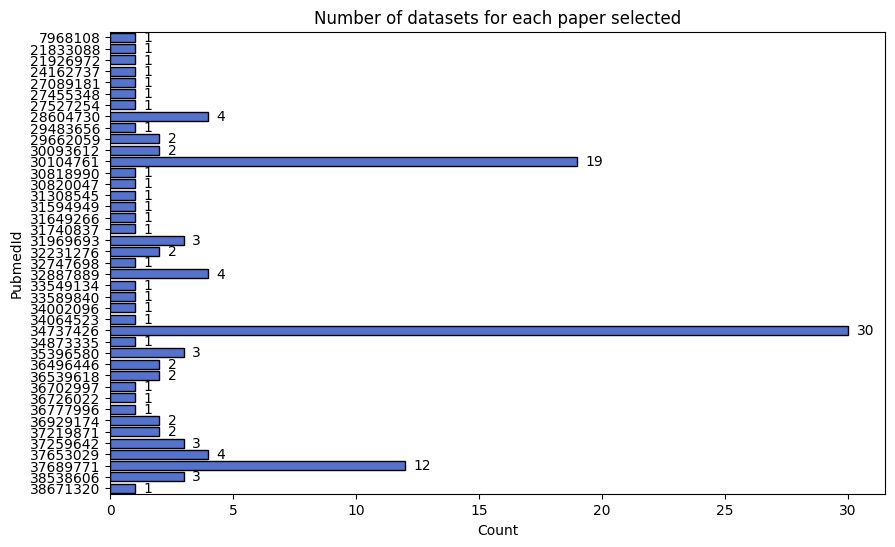

In [10]:
plt.figure(figsize=(10, 6))
a = sns.countplot(y='pubmedId', data=csv, color="royalblue", linewidth=1, edgecolor='black', dodge=True)

for container in a.containers:
    labels = [f'{height:.0f}' if height > 0 else '' for height in container.datavalues]
    a.bar_label(container, labels=labels, label_type="edge", padding=6)
    
plt.xlabel('Count')
plt.ylabel('PubmedId')
plt.title('Number of datasets for each paper selected')
plt.show()


Text(0, 0.5, 'Count')

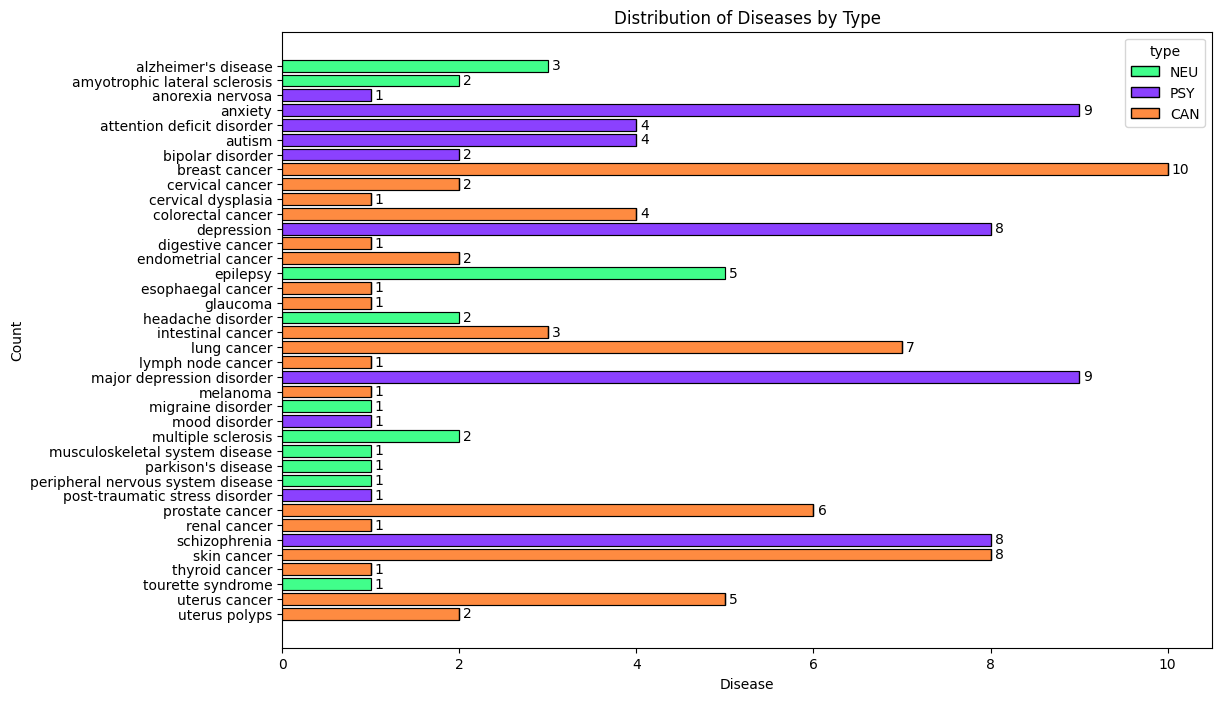

In [11]:
fig, ax = plt.subplots(figsize=(12, 8))
a = sns.histplot(csv, y="disease", hue="type", multiple="stack", binwidth=1, ax=ax, shrink=.8, palette=type_palette)
# plt.xticks(rotation=0)

# Adding labels for each container
for container in a.containers:
    labels = [f'{height:.0f}' if height > 0 else '' for height in container.datavalues]
    a.bar_label(container, labels=labels, label_type="edge", padding=3)

# Adding title and labels
ax.set_title('Distribution of Diseases by Type')
ax.set_xlabel('Disease')
ax.set_ylabel('Count')


Text(0, 0.5, 'Count')

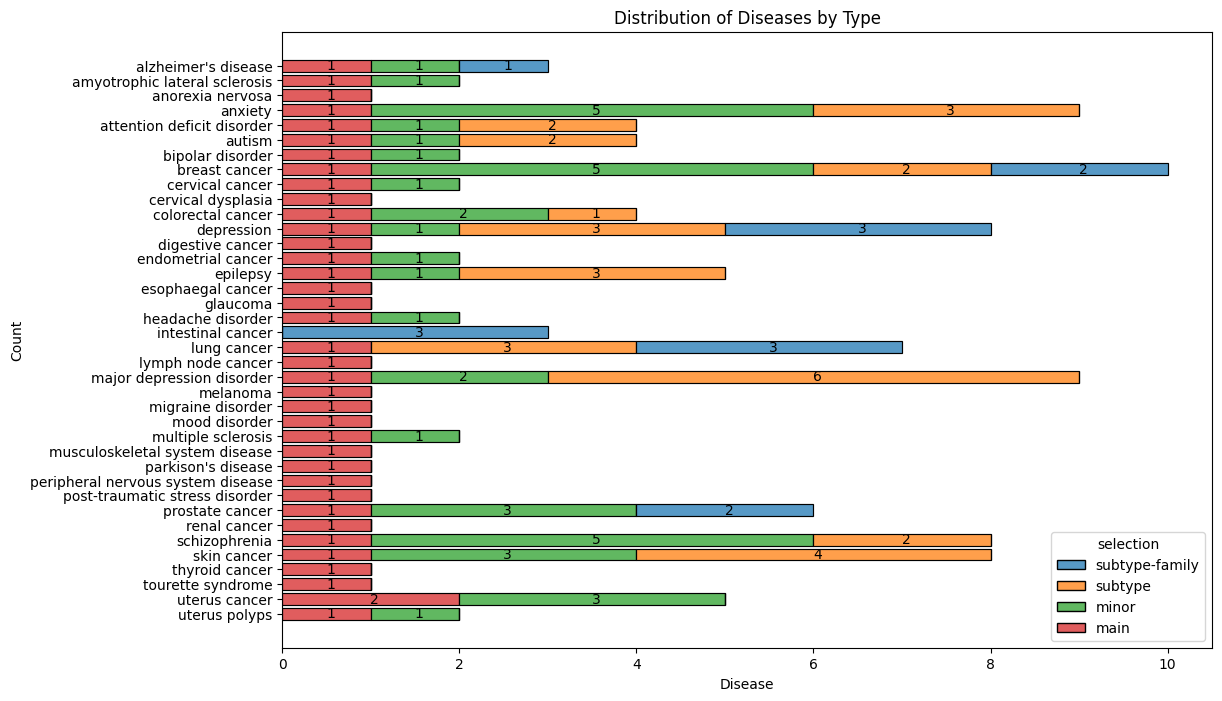

In [24]:
fig, ax = plt.subplots(figsize=(12, 8))
a = sns.histplot(csv, y="disease", hue="selection", multiple="stack", hue_order=["subtype-family","subtype","minor","main"], binwidth=1, ax=ax, shrink=.8)
# plt.xticks(rotation=0)

# Adding labels for each container
for container in a.containers:
    labels = [f'{height:.0f}' if height > 0 else '' for height in container.datavalues]
    a.bar_label(container, labels=labels, label_type="center", padding=3)

# Adding title and labels
ax.set_title('Distribution of Diseases by Type')
ax.set_xlabel('Disease')
ax.set_ylabel('Count')

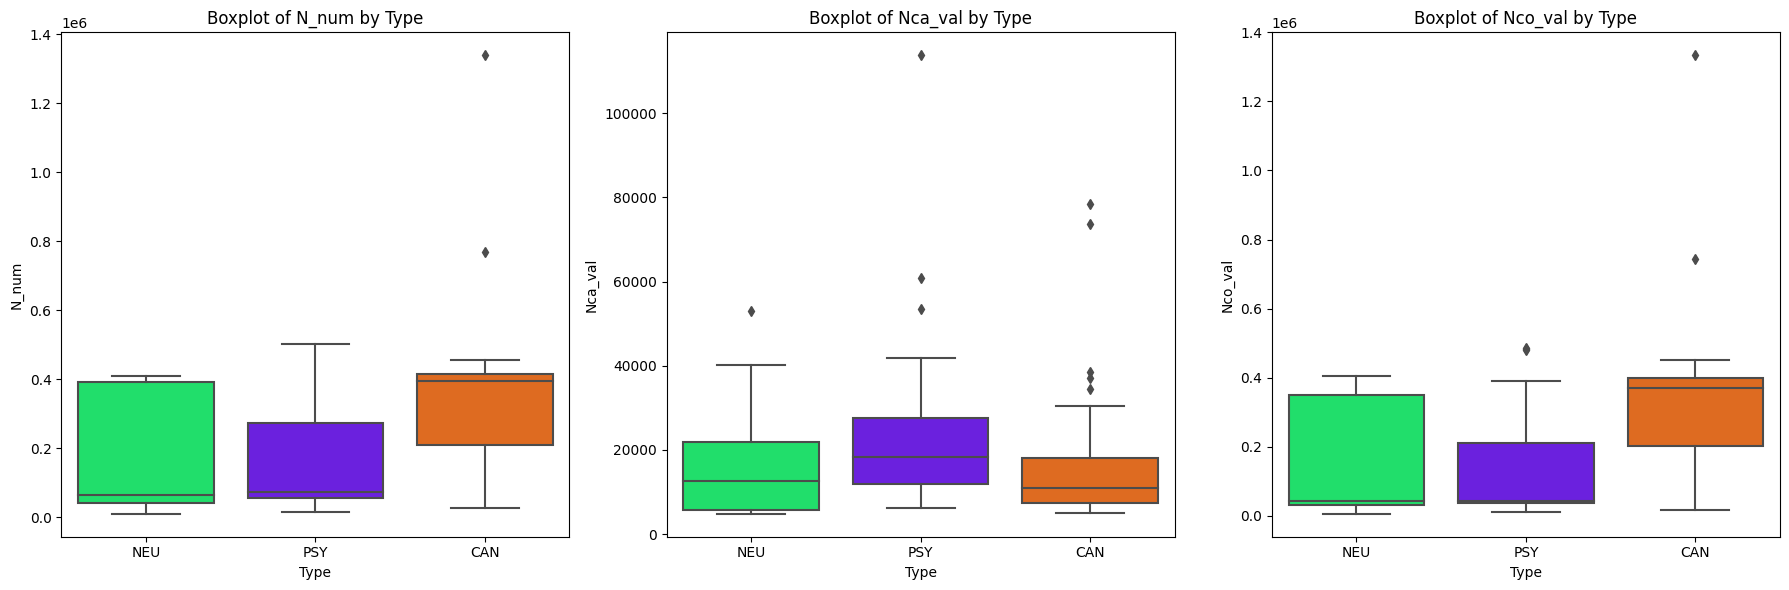

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Boxplot for N_num
sns.boxplot(x='type', y='N_num', data=csv, ax=axes[0], palette=type_palette)
axes[0].set_title('Boxplot of N_num by Type')
axes[0].set_xlabel('Type')
axes[0].set_ylabel('N_num')

# Boxplot for Nca_val
sns.boxplot(x='type', y='Nca_val', data=csv, ax=axes[1], palette=type_palette)
axes[1].set_title('Boxplot of Nca_val by Type')
axes[1].set_xlabel('Type')
axes[1].set_ylabel('Nca_val')

# Boxplot for Nco_val
sns.boxplot(x='type', y='Nco_val', data=csv, ax=axes[2], palette=type_palette)
axes[2].set_title('Boxplot of Nco_val by Type')
axes[2].set_xlabel('Type')
axes[2].set_ylabel('Nco_val')

# Show the plot
plt.tight_layout()
plt.show()


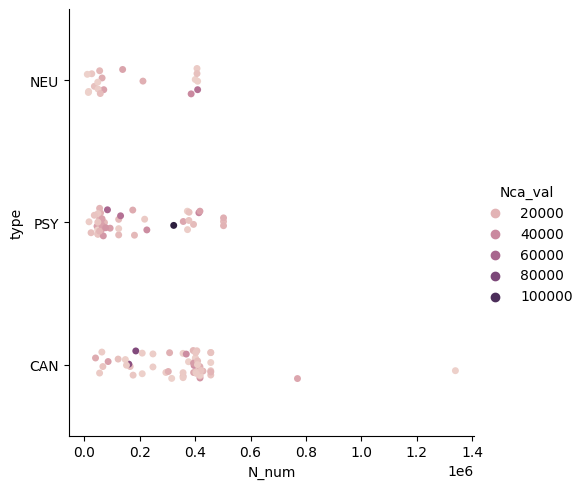

In [14]:
sns.catplot(data=csv, y="type", x="N_num", hue="Nca_val")

In [15]:
can = csv[csv["type"]=="CAN"]
psy = csv[csv["type"]=="PSY"]
neu = csv[csv["type"]=="NEU"]

Text(0.5, 1.0, 'Total Size distribution segregated by Case size')

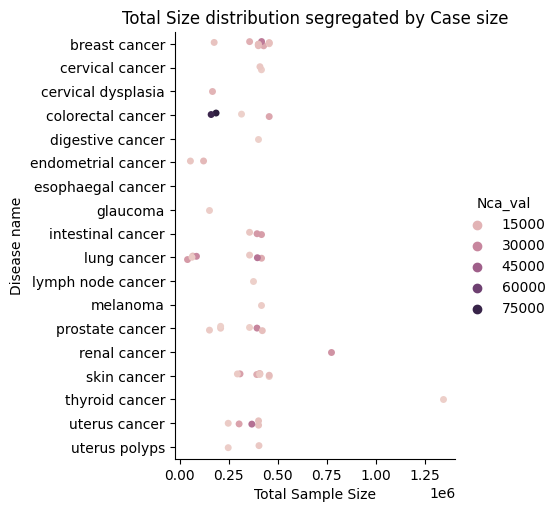

In [16]:
sns.catplot(data=can, y="disease", x="N_num", hue="Nca_val")
plt.xlabel('Total Sample Size')
plt.ylabel('Disease name')
plt.title('Total Size distribution segregated by Case size')

Text(0.5, 1.0, 'Total Size distribution segregated by Case size')

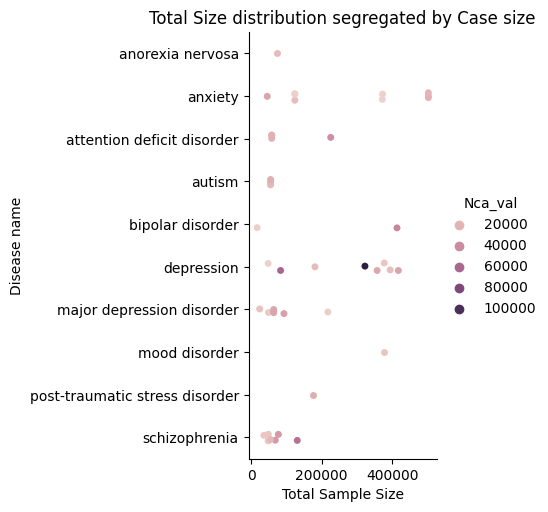

In [17]:
sns.catplot(data=psy, y="disease", x="N_num", hue="Nca_val")
plt.xlabel('Total Sample Size')
plt.ylabel('Disease name')
plt.title('Total Size distribution segregated by Case size')

Text(0.5, 1.0, 'Total Size distribution segregated by Case size')

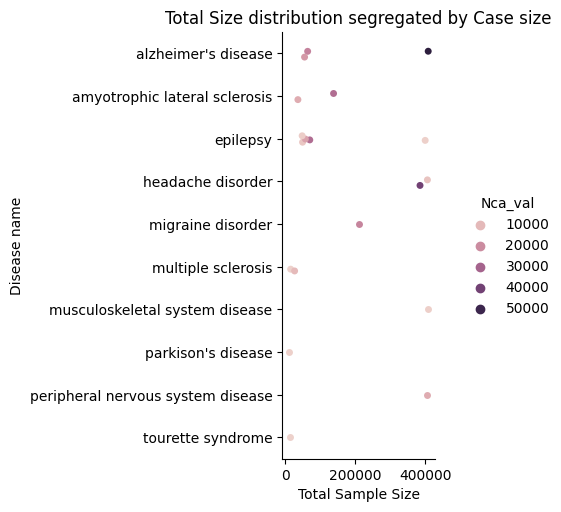

In [18]:
sns.catplot(data=neu, y="disease", x="N_num", hue="Nca_val")
plt.xlabel('Total Sample Size')
plt.ylabel('Disease name')
plt.title('Total Size distribution segregated by Case size')

In [19]:
csv['combination'] = (csv['z'].notnull().astype(int).astype(str) + 
                      csv['b'].notnull().astype(int).astype(str) + 
                      csv['OR'].notnull().astype(int).astype(str))

# Binary representation to see whether the column has a value according to the combination
combination_labels = {
    '100': 'Z-SCORE',
    '010': 'BETA',
    '001': 'ODDS RATIO',
    '110': 'Z-SCORE AND BETA',
    '101': 'Z-SCORE AND ODDS RATIO',
    '011': 'BETA AND ODDS RATIO',
    '111': 'ALL THREE',
	'000': 'NONE'
}
csv['combination'] = csv['combination'].map(combination_labels)

combination_counts = csv['combination'].value_counts().reset_index()
combination_counts.columns = ['Combination', 'Count']

Text(0.5, 1.0, 'Distribution of Studies by Presence of z, b, OR')

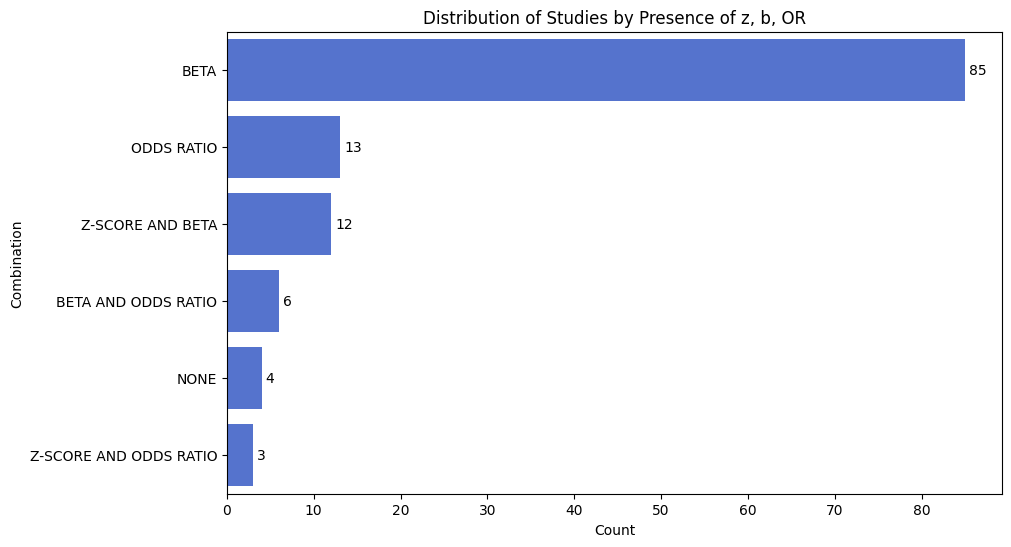

In [20]:
plt.figure(figsize=(10, 6))
a = sns.barplot(x='Count', y='Combination', data=combination_counts, color="royalblue")

for container in a.containers:
    labels = [f'{height:.0f}' if height > 0 else '' for height in container.datavalues]
    a.bar_label(container, labels=labels, label_type="edge", padding=3)
    
plt.xlabel('Count')
plt.ylabel('Combination')
plt.title('Distribution of Studies by Presence of z, b, OR')
